# **To Install Tensorlow and Open-CV**


In [ ]:
!pip install tensorflow opencv-python matplotlib

# **Importing the libs and setting up GPU**

In [ ]:
import tensorflow as tf
import os

In [ ]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
  tf.config.experimental.set_memory_growth(gpu,True)
  # to aviod out of memory errors

In [ ]:
gpus = tf.config.experimental.list_physical_devices('GPU')
gpus

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# **Data Cleaning Process**

In [ ]:
import cv2

In [ ]:
import imghdr
from matplotlib import pyplot as plt

/tmp/ipython-input-3861832242.py:1: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [ ]:
image_exts = ['jpeg','jpg', 'bmp', 'png']

In [ ]:
data_dir = '/content/drive/MyDrive/DataSets/temp/prashik 2nd/temp'

In [ ]:
os.listdir(data_dir)

['2-1', '0', '4-3', '5-6', '7-8']

In [ ]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try:
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts:
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e:
            print('Issue with image {}'.format(image_path))
            # os.remove(image_path)

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

# **Seperating Data into classes and also dividing it into Batches using Tenserflow keras utilities**

In [ ]:
data = tf.keras.utils.image_dataset_from_directory(data_dir,shuffle=True)

Found 4289 files belonging to 5 classes.


In [ ]:

data_iterator = data.as_numpy_iterator()

In [ ]:
batch = data_iterator.next()

In [ ]:
batch[0].shape

(32, 256, 256, 3)

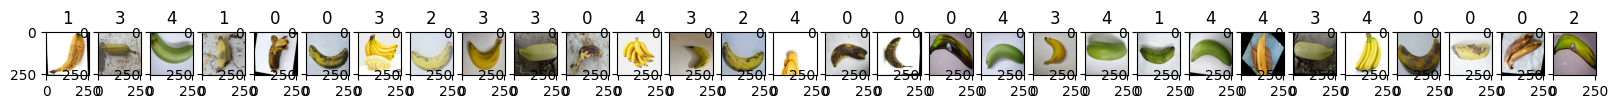

In [ ]:
fig, ax = plt.subplots(ncols=30, figsize=(20,20))
for idx, img in enumerate(batch[0][:30]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

# **Scaling the Pilxel values from 0-255 to 0-1 for easier Computation**

In [ ]:
data = data.map(lambda x,y: (x/255, y))

In [ ]:
scaled_iterator = data.as_numpy_iterator()

In [ ]:
batch = scaled_iterator.next()

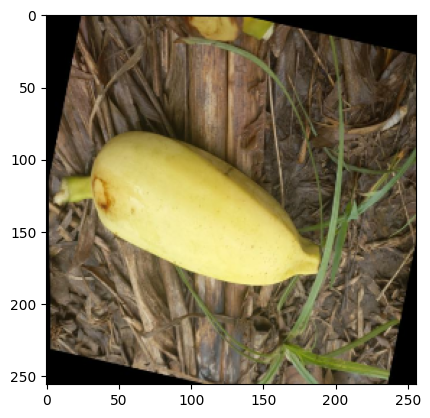

In [ ]:
plt.imshow(batch[0][0])

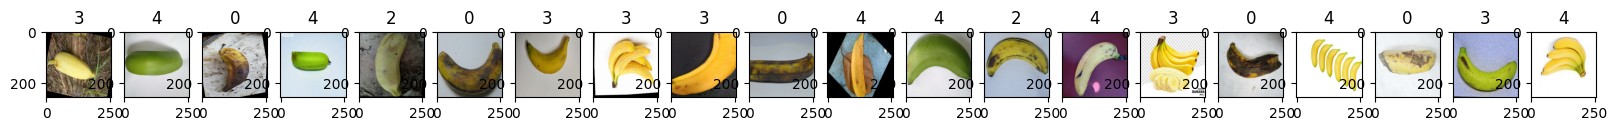

In [ ]:
fig, ax = plt.subplots(ncols=20, figsize=(20,20))
for idx, img in enumerate(batch[0][:20]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(batch[1][idx])

# **Splitting the Batches of Data into Training, Testing and Validating Datasets**

In [ ]:
len(data)

135

In [ ]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)+1
test_size = int(len(data)*.1)+1

In [ ]:
train_size

151

In [ ]:
val_size

44

In [ ]:
test_size

22

In [ ]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [ ]:
print(len(train),len(val),len(test))

94 28 13


# **Building The Model**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

**Using Data Augmentaion to make variations of images using single image**

---


This does following things:

1.   It helps us expand our data set ((Original size) + (No. of augmentaion layers*Original size))
2.   Reduces overfitting by artificially increasing the size and diversity of the training dataset



In [ ]:
data_augmentation = tf.keras.Sequential([
            tf.keras.layers.RandomFlip("horizontal_and_vertical"),
            tf.keras.layers.RandomRotation(0.1),
            tf.keras.layers.RandomZoom(0.2),
            tf.keras.layers.RandomContrast(0.2)
        ])

Starting to add layers in the model

In [ ]:

model = Sequential()

In [ ]:
model.add(data_augmentation)
model.add(Conv2D(filters = 64, kernel_size=(3,3), activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(filters = 64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(filters = 32, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.25)) # this makes 25% of the neurons "0" reducing chance of overfitting
model.add(Flatten()) # making output 1D or just an array
model.add(Dense(256, activation='relu')) # converting big array into array of size 256 using relu function
model.add(Dense(64, activation='relu'))
model.add(Dense(5, activation='softmax')) #converting the final output into an array of size 5 cause we have 5 features

NameError: name 'model' is not defined

In [ ]:
model.compile('adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['accuracy'])

the summary is not showing anything because of the augmentaion layer

In [ ]:

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# **Training the model**

In [ ]:

logdir='/content/drive/MyDrive/DataSets/HAPPYSAD/logs'

In [ ]:

tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [ ]:
hist = model.fit(train, epochs=20, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 49s 398ms/step - accuracy: 0.3949 - loss: 1.4452 - val_accuracy: 0.6138 - val_loss: 0.9402
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 38s 401ms/step - accuracy: 0.5874 - loss: 1.0021 - val_accuracy: 0.5993 - val_loss: 1.0075
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 38s 408ms/step - accuracy: 0.6285 - loss: 0.9308 - val_accuracy: 0.7042 - val_loss: 0.7734
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 39s 412ms/step - accuracy: 0.6708 - loss: 0.8139 - val_accuracy: 0.7009 - val_loss: 0.7285
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 40s 423ms/step - accuracy: 0.6781 - loss: 0.8088 - val_accuracy: 0.7143 - val_loss: 0.7116
Epoch 6/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 38s 403ms/step - accuracy: 0.6992 - loss: 0.7545 - val_accuracy: 0.7299 - val_loss: 0.6767
Epoch 7/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 38s 403ms/step - accuracy: 0.7369 - loss: 0.6926 - val_accuracy: 0.7344 - val_loss: 0.6230
Epoch 8/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 39s 412ms/step - accuracy: 0.7330 - loss: 0.6370 - val_accu

# **Plotting valuable insights**

This loss curve helps in determining weather the model is overfitting or not.

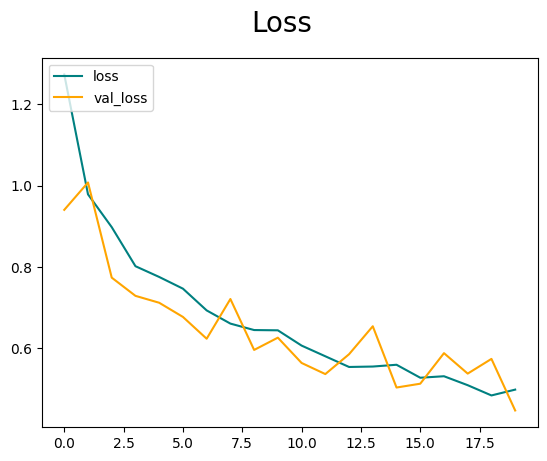

In [ ]:

fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

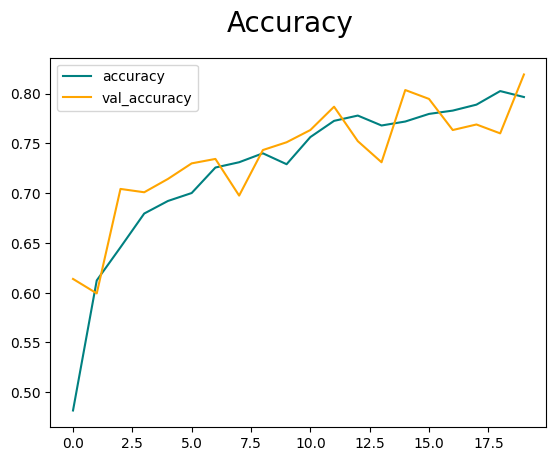

In [ ]:

fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

# **Evaluation**

In [ ]:
model.evaluate(test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 158ms/step - accuracy: 0.8108 - loss: 0.4579


[0.4908236563205719, 0.8103896379470825]

In [ ]:
import cv2

In [ ]:
# Assuming `data` is the original dataset loaded before scaling
class_names = tf.keras.utils.image_dataset_from_directory(data_dir).class_names
print(class_names)

Found 4289 files belonging to 5 classes.
['0', '2-1', '4-3', '5-6', '7-8']


# **Testing on custom inputs**

Saving 4.jpg to 4 (2).jpg


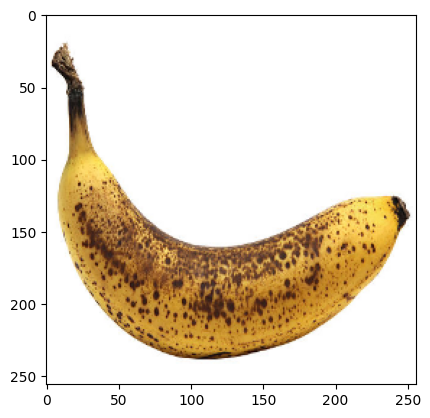

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[0.6153407  0.2642738  0.11667605 0.00162062 0.00208878]]
0


In [ ]:
from google.colab import files
uploaded = files.upload()
for filename in uploaded.keys():
  img = cv2.imread(filename)
  # Convert BGR to RGB
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  resize = tf.image.resize(img, (256,256))
  # Scale the image pixels by 255
  scaled_img = resize/255
  plt.imshow(scaled_img)
  plt.show()
  yhat = model.predict(np.expand_dims(scaled_img,0))
  print(yhat)
  print(class_names[np.argmax(yhat)])

# **Finally Saving the model for Deployment**

In [ ]:
from tensorflow.keras.models import load_model
model.save(os.path.join('/content/drive/MyDrive/DataSets/temp/models','bananaV2.h5'))